# Notebook 04 — Sensitivity to the decay parameter λ

**Goal:** Assess how the geometric decay parameter λ affects cooperation at L > 1.
At L=1 the kernel normalizes to α=[1.0] regardless of λ, so λ is only meaningful for L≥2.

Kernel: α_d = λ^d / Σ λ^k, d = 0..L−1.
- λ → 0: all weight on first circle → equivalent to L=1.
- λ = 0.5: each additional circle carries half the weight of the previous one (default).
- λ → 1: uniform weighting across all L circles.

Comparison with the PNAS Nexus 2024 linear kernel [(4−d)/3] at L=4 (weights ≈ 1, 0.75, 0.5, 0.25)
corresponds approximately to λ ≈ 0.65–0.7.

Networks: BA z = 4 and BA z = 16 (sufficient to show the argument; ER adds compute without new insight for this sensitivity analysis).  
Update rule: Fermi (K = 0.1), correlated duplex.  
Parameters: λ ∈ {0.1, 0.25, 0.5, 0.75, 0.9}, L ∈ {2, 3, 4},
b ∈ [1.0, 2.0], θ ∈ [0.0, 1.0], N = 1000, 100 replications.

**Structure:**
- **Part I — Simulation:** saves to `data/04-*.csv`. Run once.
- **Part II — Figures:** loads CSVs, makes all plots independently.

In [1]:
# ── Shared: imports and parameters ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import model

N          = 1000
n_rep      = 100
L_VALUES   = [2, 3, 4]          # L=1 excluded: lambda has no effect there
LAM_VALUES = [0.1, 0.25, 0.5, 0.75, 0.9]
K_fermi    = 0.1
b_vals     = np.round(np.linspace(1.0, 2.0, 11), 2)
th_vals    = np.round(np.linspace(0.0, 1.0, 11), 2)
NET_SEED   = 0
SIM_SEED   = 0
N_JOBS     = -1

# Only BA networks — sufficient for the λ sensitivity argument
NETWORKS = [
    ('BA_z4',  'BA', 4,  r'BA, $z=4$'),
    ('BA_z16', 'BA', 16, r'BA, $z=16$'),
]

def lam_tag(lam):
    return f"{lam:.2f}".replace('.', 'p')   # 0.50 → '0p50'

os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)

# Print kernel weights for each (L, lambda) combination
print('Kernel weights α_d = λ^d / Σλ^k:\n')
for L in L_VALUES:
    for lam in LAM_VALUES:
        al = model.geometric_kernel(L, lam)
        print(f"  L={L}  λ={lam:.2f}  α={np.round(al, 3)}")
    print()

Kernel weights α_d = λ^d / Σλ^k:

  L=2  λ=0.10  α=[0.909 0.091]
  L=2  λ=0.25  α=[0.8 0.2]
  L=2  λ=0.50  α=[0.667 0.333]
  L=2  λ=0.75  α=[0.571 0.429]
  L=2  λ=0.90  α=[0.526 0.474]

  L=3  λ=0.10  α=[0.901 0.09  0.009]
  L=3  λ=0.25  α=[0.762 0.19  0.048]
  L=3  λ=0.50  α=[0.571 0.286 0.143]
  L=3  λ=0.75  α=[0.432 0.324 0.243]
  L=3  λ=0.90  α=[0.369 0.332 0.299]

  L=4  λ=0.10  α=[0.9   0.09  0.009 0.001]
  L=4  λ=0.25  α=[0.753 0.188 0.047 0.012]
  L=4  λ=0.50  α=[0.533 0.267 0.133 0.067]
  L=4  λ=0.75  α=[0.366 0.274 0.206 0.154]
  L=4  λ=0.90  α=[0.291 0.262 0.236 0.212]



---
## Part I — Simulation
*Run once. Each (network, L, λ) triplet is cached separately.*

In [2]:
# ── Build networks ──────────────────────────────────────────────────────────
graphs = {
    key: model.build_network(topo, N, z, seed=NET_SEED)
    for key, topo, z, _ in NETWORKS
}

for key, topo, z, label in NETWORKS:
    G = graphs[key]
    k = 2 * G.number_of_edges() / G.number_of_nodes()
    d = nx.diameter(G)
    print(f"{label:14s}  N={G.number_of_nodes()}  <k>={k:.2f}  diameter={d}")

BA, $z=4$       N=1000  <k>=3.99  diameter=7


BA, $z=16$      N=1000  <k>=15.87  diameter=4


In [3]:
# ── Pre-compile JIT kernels ─────────────────────────────────────────────────
model.warm_up()
print('JIT kernels compiled.')

JIT kernels compiled.


In [4]:
# ── Run sweeps (correlated duplex, vary L and λ) ─────────────────────────────
# shells_csr only depends on (G, L), not on λ — build once per (network, L).

for key, topo, z, label in NETWORKS:
    G      = graphs[key]
    gp, gd = model.game_csr(G)
    for L in L_VALUES:
        sp, sd = model.shells_csr(G, L)   # build once per (network, L)
        for lam in LAM_VALUES:
            path = f"data/04-{key}-L{L}-lam{lam_tag(lam)}.csv"
            if os.path.exists(path):
                print(f"  skip: {path}")
                continue
            print(f"  running {label}  L={L}  λ={lam} ...", flush=True)
            al = model.geometric_kernel(L, lam)
            df = model.run_sweep(
                gp, gd, sp, sd, al,
                b_vals, th_vals,
                K=K_fermi, n_rep=n_rep,
                n_jobs=N_JOBS, base_seed=SIM_SEED,
                update_rule='fermi',
            )
            df.to_csv(path, index=False)
            print(f"  saved: {path}")

print('Part I done.')

  running BA, $z=4$  L=2  λ=0.1 ...


  saved: data/04-BA_z4-L2-lam0p10.csv
  running BA, $z=4$  L=2  λ=0.25 ...


  saved: data/04-BA_z4-L2-lam0p25.csv
  running BA, $z=4$  L=2  λ=0.5 ...


  saved: data/04-BA_z4-L2-lam0p50.csv
  running BA, $z=4$  L=2  λ=0.75 ...


  saved: data/04-BA_z4-L2-lam0p75.csv
  running BA, $z=4$  L=2  λ=0.9 ...


...

  saved: data/04-BA_z16-L4-lam0p10.csv
  running BA, $z=16$  L=4  λ=0.25 ...


  saved: data/04-BA_z16-L4-lam0p25.csv
  running BA, $z=16$  L=4  λ=0.5 ...


  saved: data/04-BA_z16-L4-lam0p50.csv
  running BA, $z=16$  L=4  λ=0.75 ...


  saved: data/04-BA_z16-L4-lam0p75.csv
  running BA, $z=16$  L=4  λ=0.9 ...


  saved: data/04-BA_z16-L4-lam0p90.csv
Part I done.


---
## Part II — Figures
*Loads CSVs from `data/` independently of Part I.*

In [5]:
# ── Load results ─────────────────────────────────────────────────────────────
data = {}
for key, topo, z, label in NETWORKS:
    for L in L_VALUES:
        for lam in LAM_VALUES:
            path = f"data/04-{key}-L{L}-lam{lam_tag(lam)}.csv"
            data[(key, L, lam)] = pd.read_csv(path)
print(f'Loaded {len(data)} DataFrames.')

Loaded 30 DataFrames.


In [6]:
# ── Figure settings ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 120,
})

CMAP       = 'Blues'
VMIN, VMAX = 0.0, 1.0
THETA_SHOW = [0.3, 0.5, 0.7]

# Colour per lambda value
import matplotlib.cm as cm
LAM_CMAP   = cm.viridis
LAM_COLORS = {lam: LAM_CMAP(i / (len(LAM_VALUES) - 1)) for i, lam in enumerate(LAM_VALUES)}

# Network to show in the focused figures (choose one for clarity)
KEY_FOCUS  = 'BA_z4'
L_FOCUS    = 4      # most informative for λ sensitivity

db, dt = b_vals[1] - b_vals[0], th_vals[1] - th_vals[0]
EXTENT = [b_vals[0]-db/2, b_vals[-1]+db/2, th_vals[0]-dt/2, th_vals[-1]+dt/2]

def rho_matrix(df):
    return (
        df.pivot(index='theta', columns='b', values='rho_mean')
          .sort_index(ascending=True)
          .values
    )

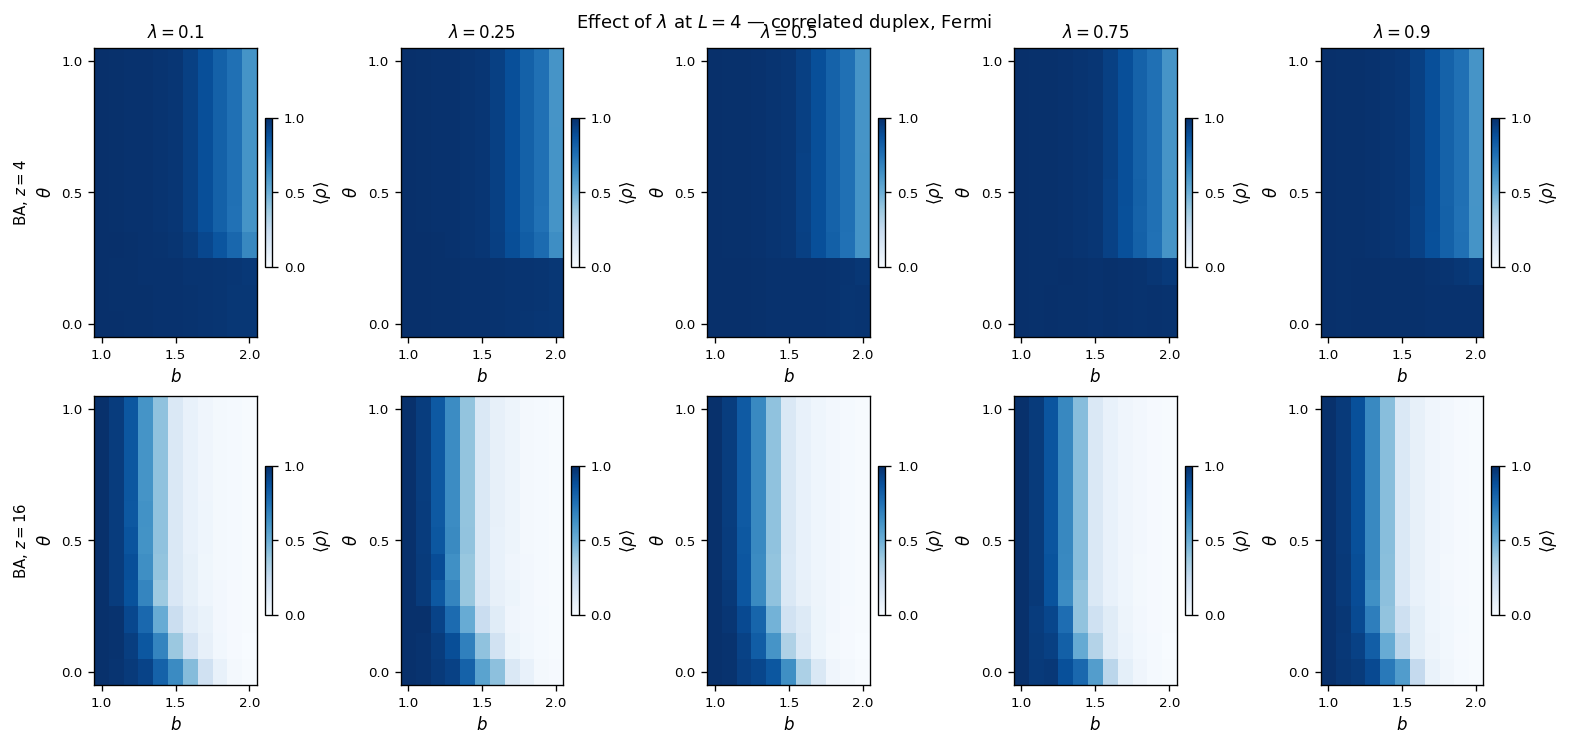

Saved figures/04-heatmaps-lambda.{pdf,png}


In [7]:
# ── Figure 1: heatmaps — effect of λ at fixed L, two networks ────────────────
# Rows = BA z=4 and BA z=16; cols = λ values (at L_FOCUS).
NETS_SHOW = [('BA_z4', r'BA, $z=4$'), ('BA_z16', r'BA, $z=16$')]

fig1, axes = plt.subplots(
    len(NETS_SHOW), len(LAM_VALUES),
    figsize=(13, 6),
    constrained_layout=True,
)

for row, (key, label) in enumerate(NETS_SHOW):
    for col, lam in enumerate(LAM_VALUES):
        ax  = axes[row, col]
        mat = rho_matrix(data[(key, L_FOCUS, lam)])
        im  = ax.imshow(
            mat, origin='lower', aspect='auto',
            vmin=VMIN, vmax=VMAX, cmap=CMAP, extent=EXTENT,
        )
        ax.set_xlabel('$b$')
        ax.set_ylabel('$\\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if row == 0:
            ax.set_title(f'$\\lambda={lam}$', fontweight='bold')
        if col == 0:
            ax.text(
                -0.45, 0.5, label, transform=ax.transAxes,
                rotation=90, va='center', ha='center', fontsize=9,
            )
        cb = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label('$\\langle\\rho\\rangle$')
        cb.set_ticks([0, 0.5, 1.0])

fig1.suptitle(
    f'Effect of $\\lambda$ at $L={L_FOCUS}$ — correlated duplex, Fermi', y=1.01,
)
fig1.savefig('figures/04-heatmaps-lambda.pdf', bbox_inches='tight')
fig1.savefig('figures/04-heatmaps-lambda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/04-heatmaps-lambda.{pdf,png}')

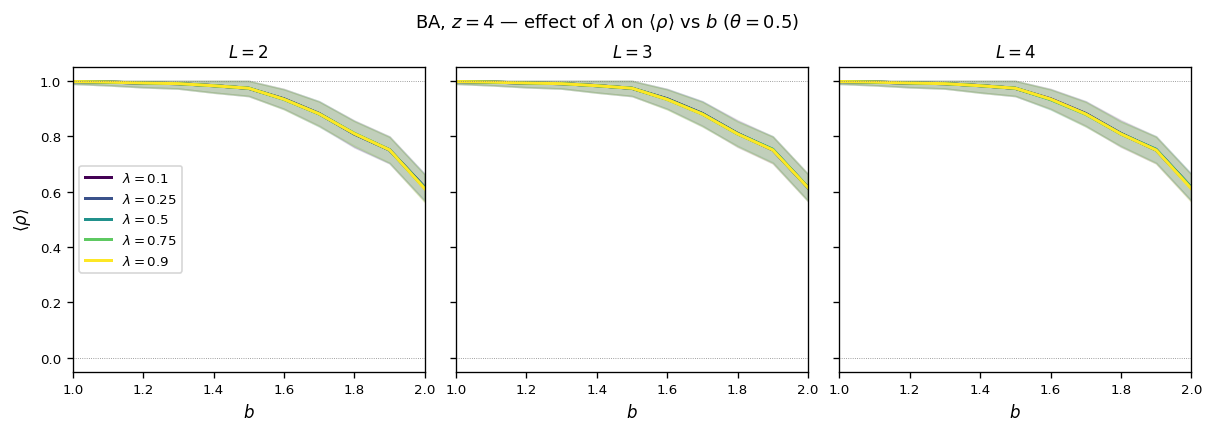

Saved figures/04-marginals-lambda.{pdf,png}


In [8]:
# ── Figure 2: marginals rho vs b — effect of λ for each L ────────────────────
# Focus: one network (KEY_FOCUS), rows = θ values, cols = L values.
TH_PLOT = 0.5

fig2, axes2 = plt.subplots(
    1, len(L_VALUES),
    figsize=(10, 3.5),
    constrained_layout=True,
    sharey=True,
)

key_label = dict(zip(
    [k for k, *_ in NETWORKS],
    [lbl for *_, lbl in NETWORKS],
))[KEY_FOCUS]

for col, L in enumerate(L_VALUES):
    ax = axes2[col]
    for lam in LAM_VALUES:
        df  = data[(KEY_FOCUS, L, lam)]
        sub = df[np.isclose(df['theta'], TH_PLOT)].sort_values('b')
        ax.plot(
            sub['b'], sub['rho_mean'],
            color=LAM_COLORS[lam], label=f'$\\lambda={lam}$', lw=1.8,
        )
        ax.fill_between(
            sub['b'],
            (sub['rho_mean'] - sub['rho_std']).clip(0),
            (sub['rho_mean'] + sub['rho_std']).clip(0, 1),
            alpha=0.10, color=LAM_COLORS[lam],
        )
    ax.set_title(f'$L={L}$')
    ax.set_xlabel('$b$')
    if col == 0:
        ax.set_ylabel('$\\langle\\rho\\rangle$')
        ax.legend(fontsize=8)
    ax.set_xlim(1.0, 2.0)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axhline(1, color='grey', lw=0.5, ls=':')

fig2.suptitle(
    f'{key_label} — effect of $\\lambda$ on $\\langle\\rho\\rangle$ vs $b$ ($\\theta={TH_PLOT}$)',
)
fig2.savefig('figures/04-marginals-lambda.pdf', bbox_inches='tight')
fig2.savefig('figures/04-marginals-lambda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/04-marginals-lambda.{pdf,png}')

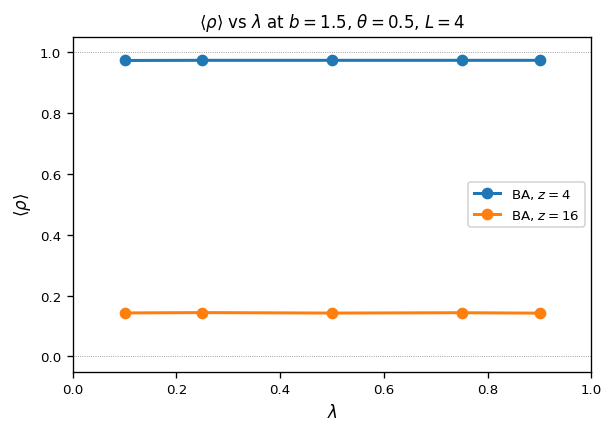

Saved figures/04-rho-vs-lambda.{pdf,png}


In [9]:
# ── Figure 3: all networks — rho vs lambda at fixed (b, theta, L) ─────────────
# Shows how the cooperation fraction varies as a function of λ at a representative point.
B_FIXED  = 1.5
TH_FIXED = 0.5
L_FIXED  = 4

fig3, ax3 = plt.subplots(figsize=(5, 3.5), constrained_layout=True)

for key, topo, z, label in NETWORKS:
    rho_vs_lam = []
    for lam in LAM_VALUES:
        df  = data[(key, L_FIXED, lam)]
        row = df[np.isclose(df['b'], B_FIXED) & np.isclose(df['theta'], TH_FIXED)]
        rho_vs_lam.append(float(row['rho_mean'].iloc[0]))
    ax3.plot(LAM_VALUES, rho_vs_lam, 'o-', label=label, lw=1.8)

ax3.set_xlabel('$\\lambda$')
ax3.set_ylabel('$\\langle\\rho\\rangle$')
ax3.set_title(
    f'$\\langle\\rho\\rangle$ vs $\\lambda$ at $b={B_FIXED}$, $\\theta={TH_FIXED}$, $L={L_FIXED}$'
)
ax3.legend(fontsize=8)
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.05, 1.05)
ax3.axhline(0, color='grey', lw=0.5, ls=':')
ax3.axhline(1, color='grey', lw=0.5, ls=':')

fig3.savefig('figures/04-rho-vs-lambda.pdf', bbox_inches='tight')
fig3.savefig('figures/04-rho-vs-lambda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/04-rho-vs-lambda.{pdf,png}')

## Observations

*(Fill in after running)*

- Is ⟨ρ⟩ monotonically increasing or decreasing with λ? Does it depend on (b, θ, L, topology)?
- At what λ value is the effect of long-range vigilance maximized?
- The PNAS Nexus 2024 linear kernel at L=4 gives weights ≈ (1, 0.75, 0.5, 0.25),
  which corresponds to λ ≈ 0.65–0.7 in the geometric kernel. Does the cooperative
  behavior at this λ agree with the experimental regime?
- Is the model robust to the choice of λ, or is behavior sensitive to it?